In [2]:
#1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
#2. Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from torchvision import models
import os
from PIL import Image
from torch.utils.data import DataLoader, random_split, Subset
import time
from torchsummary import summary
import pandas as pd


# **Image Preprocessing**

In [4]:
#3. Define Transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),             # Resize to fixed size
    transforms.RandomHorizontalFlip(),         # Augmentation
    transforms.ToTensor(),                     # Convert to tensor // scales pixel values from [0, 255] to [0, 1] (float format).
    #transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # Normalize RGB
    transforms.Normalize([0.5]*3, [0.5]*3) # each pixel is scaled from [0, 1] → [-1, 1].
])

# **Load Dataset**


In [5]:
#4. Load Dataset
data_dir = '/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/animal_10/raw-img'

# Load dataset from ImageFolder
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Print class information
print("Class to index mapping:", full_dataset.class_to_idx)
print("Number of classes:", len(full_dataset.classes))
print("Total samples in dataset:", len(full_dataset))


Class to index mapping: {'butterfly': 0, 'cat': 1, 'chicken': 2, 'cow': 3, 'dog': 4, 'elephant': 5, 'horse': 6, 'sheep': 7, 'spider': 8, 'squirrel': 9}
Number of classes: 10
Total samples in dataset: 26197


# **Data Visualization**

       Class  Size
0  butterfly  2112
1        cat  1668
2    chicken  3098
3        cow  1866
4        dog  4863
5   elephant  1446
6      horse  2623
7      sheep  1820
8     spider  4830
9   squirrel  1871
Total Samples: 26197


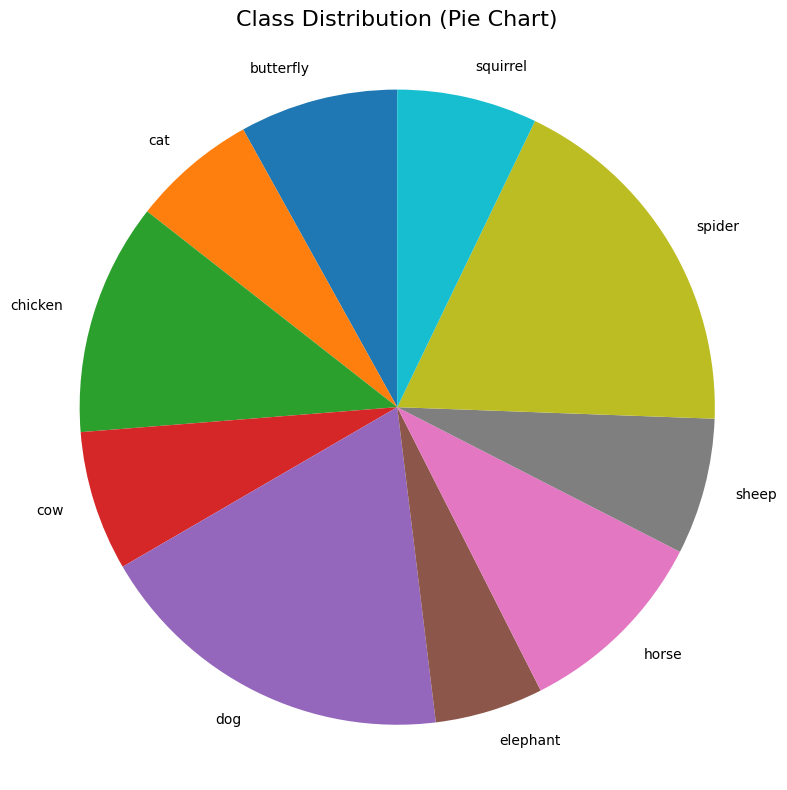

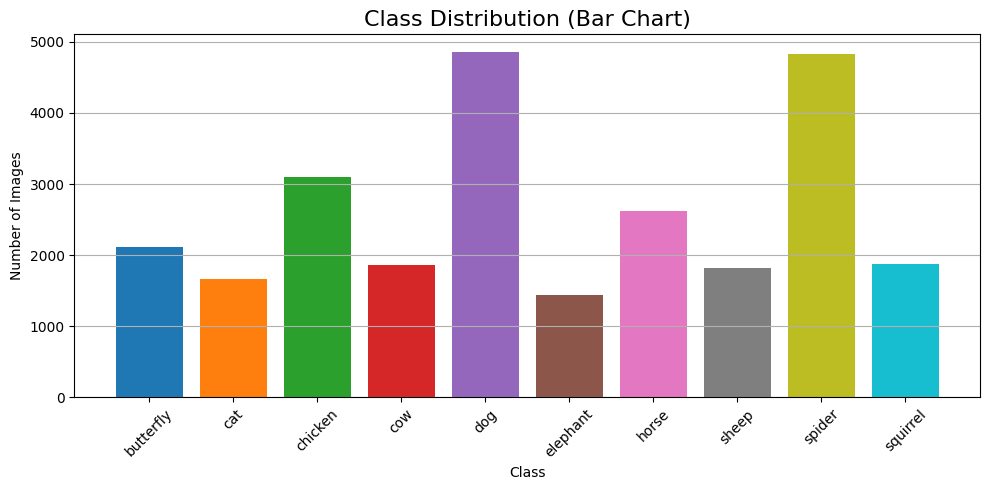

In [6]:
# Seeing the Data
# Extract class names and sizes
class_names = full_dataset.classes
class_to_idx = full_dataset.class_to_idx

# Count samples per class
class_sizes = []
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    size = len(os.listdir(class_path))
    class_sizes.append((class_name, size))

# Create DataFrame
data = pd.DataFrame(class_sizes, columns=["Class", "Size"])

# Print for verification
print(data)
print(f"Total Samples: {data['Size'].sum()}")

# Pie Chart for Class Distribution
plt.figure(figsize=(8, 8))
plt.pie(
    data['Size'],
    labels=data['Class'],
    startangle=90,
    colors=plt.cm.tab10.colors
)
plt.title("Class Distribution (Pie Chart)", fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()


# 5. Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(data['Class'], data['Size'], color=plt.cm.tab10.colors)
plt.title("Class Distribution (Bar Chart)", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA Device:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

GPU available: True
CUDA Device: Tesla T4


# **Training and Validation**

In [8]:
# 4. Split dataset (80% train, 20% validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 5. Print split information
print("\nAfter splitting:")
print(f"Training set size: {len(train_dataset)} ({len(train_dataset)/len(full_dataset):.1%})")
print(f"Validation set size: {len(val_dataset)} ({len(val_dataset)/len(full_dataset):.1%})")


After splitting:
Training set size: 20957 (80.0%)
Validation set size: 5240 (20.0%)


In [9]:
# 6. Verify one sample
sample, label = train_dataset[0]
print("\nSample verification:")
print("Image shape:", sample.shape) #torch.Size([RGB, Height, Width])
print("Label:", label, "-> Class:", full_dataset.classes[label])


Sample verification:
Image shape: torch.Size([3, 128, 128])
Label: 5 -> Class: elephant


# **Visualize sample images from train_datase**

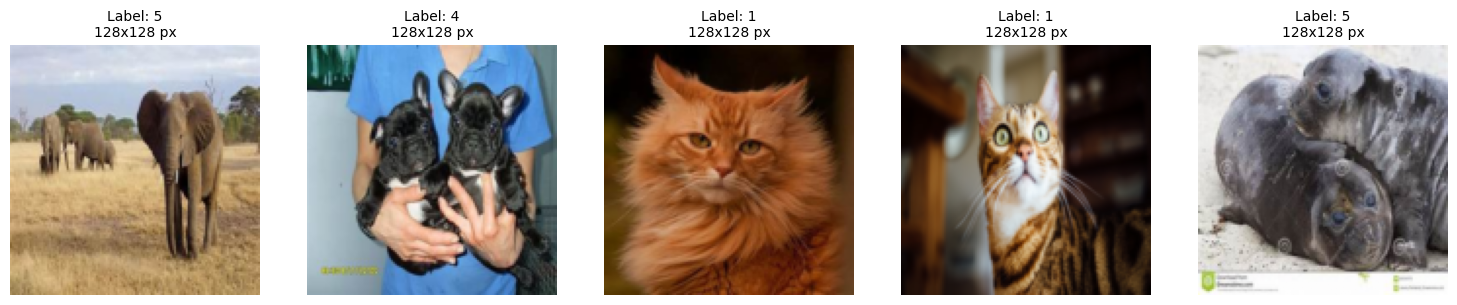

In [10]:
plt.figure(figsize=(15, 3))
for i in range(5):
    image, label = train_dataset[i]  # image: tensor [C,H,W]
    _, height, width = image.shape   # Extract pixel dimensions

    # Unnormalize for visualization (assuming normalization was mean=0.5, std=0.5)
    image_vis = image.permute(1, 2, 0) * 0.5 + 0.5  # Convert to [H,W,C] and denormalize
    #Reorders the tensor from [C, H, W] → [H, W, C] for matplotlib.

    plt.subplot(1, 5, i+1)
    plt.imshow(image_vis)
    plt.title(f"Label: {label}\n{width}x{height} px", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


# **Sample Batch**

Batch shape: torch.Size([64, 3, 128, 128])


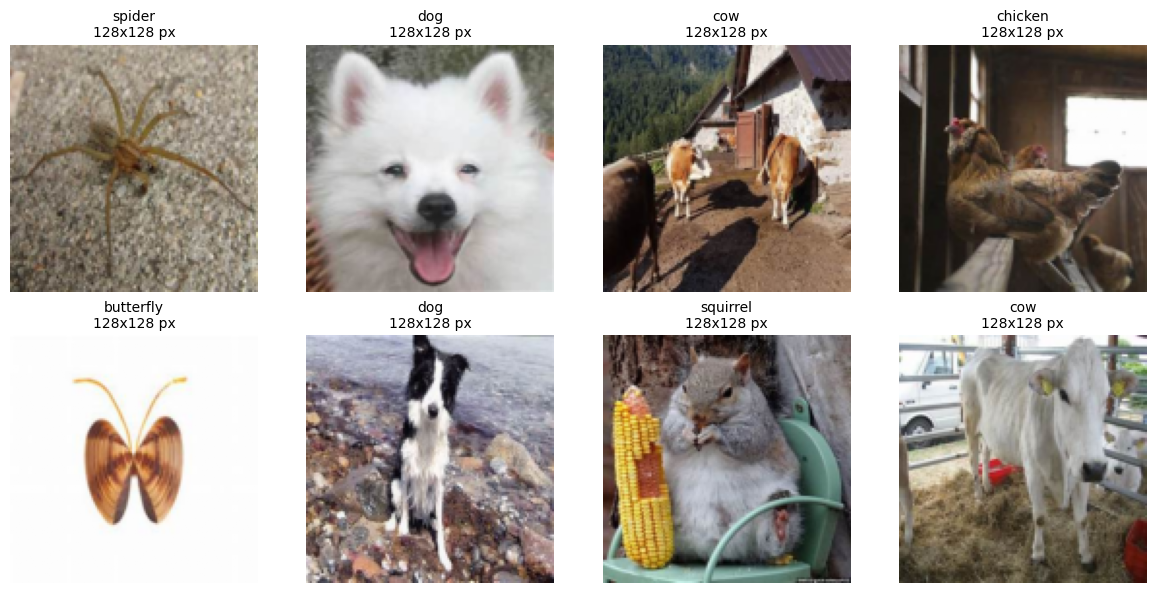

In [ ]:
# Create data loaders for train and validation sets
# load data efficiently during training and validation.
train_loader = DataLoader(
    train_dataset,
    batch_size=64,     # 32/64/128(if using GPU)
    shuffle=True,      # Ensures randomness in training
    pin_memory=True,   # Faster GPU transfers
    num_workers=2      # Parallel data loading
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=True
)

# Visualize a sample batch
batch = next(iter(train_loader))
images, labels = batch
print(f"Batch shape: {images.shape}")  # Should be [64, 3, H, W]

plt.figure(figsize=(12, 6))
for i in range(8):  # Show first 8 images
    image = images[i]
    label = labels[i].item()
    class_name = full_dataset.classes[label]

    _, height, width = image.shape  # Get pixel dimensions

    # Unnormalize and prepare image for visualization
    img_vis = image.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5

    plt.subplot(2, 4, i+1)
    plt.imshow(img_vis)
    plt.title(f"{class_name}\n{width}x{height} px", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


# **Training Epoch and Evaluation Step**

In [ ]:
# Define one epoch of training
def train_one_epoch(model, loader, optimizer, criterion, device): #Trains model for 1 epoch
    model.train()  # Set model to training mode
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()                # Clear gradients from previous step
        outputs = model(images)              # Forward pass
        loss = criterion(outputs, labels)    # Compute loss
        loss.backward()                      # Backpropagation
        optimizer.step()                     # Update weights
        total_loss += loss.item()
    return total_loss / len(loader)  # return Avg loss

# Evaluation function - evaluates the model on the validation set.
def evaluate(model, loader, criterion, device): #Tests model on validation
    model.eval()  # Set model to evaluation mode
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():  # No gradient computation during evaluation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return {
        'loss': val_loss / len(loader),
        'accuracy': acc,
        'true_labels': all_labels,
        'predictions': all_preds
    } # return Accuracy, loss, true/predicted labels


=== Training ResNet18 ===
F1 = 0.4773 | Precision = 0.4974 | Recall = 0.4951
Epoch 1/10: Train Loss = 1.5716 | Val Acc = 0.5109 | Time = 5823.7s
F1 = 0.5560 | Precision = 0.5872 | Recall = 0.5718
Epoch 2/10: Train Loss = 1.1567 | Val Acc = 0.6040 | Time = 2112.2s
F1 = 0.5917 | Precision = 0.6460 | Recall = 0.5845
Epoch 3/10: Train Loss = 0.9800 | Val Acc = 0.6344 | Time = 2112.9s
F1 = 0.6613 | Precision = 0.6711 | Recall = 0.6763
Epoch 4/10: Train Loss = 0.8488 | Val Acc = 0.6910 | Time = 2091.5s
F1 = 0.6773 | Precision = 0.7325 | Recall = 0.6554
Epoch 5/10: Train Loss = 0.7383 | Val Acc = 0.7038 | Time = 2134.7s
F1 = 0.7002 | Precision = 0.7186 | Recall = 0.7018
Epoch 6/10: Train Loss = 0.6445 | Val Acc = 0.7334 | Time = 2083.3s
F1 = 0.7270 | Precision = 0.7570 | Recall = 0.7164
Epoch 7/10: Train Loss = 0.5609 | Val Acc = 0.7546 | Time = 2116.6s
F1 = 0.7104 | Precision = 0.7375 | Recall = 0.7162
Epoch 8/10: Train Loss = 0.4792 | Val Acc = 0.7380 | Time = 2100.2s
F1 = 0.7315 | Precisio

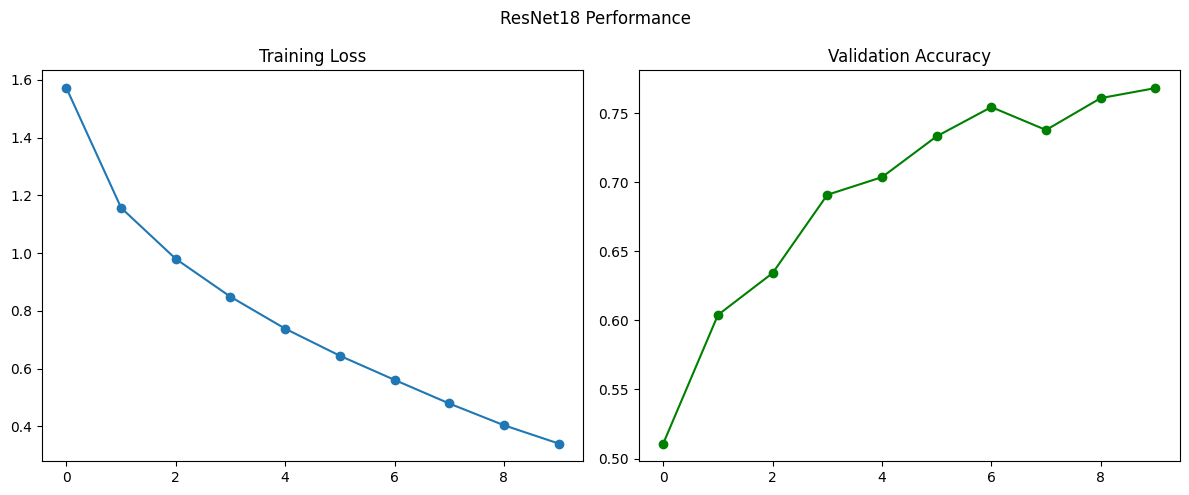

In [ ]:
# ========================
# RESNET18 TRAINING BLOCK
# ========================

# 1. Model Initialization
resnet18 = models.resnet18(weights=None)
resnet18.fc = nn.Linear(resnet18.fc.in_features, 10)  # 10 classes
resnet18.to(device)

# 2. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.parameters(), lr=0.001)
epochs = 10

# 3. Training Loop
resnet_train_losses = []
resnet_val_metrics = []
start_time = time.time()

print("=== Training ResNet18 ===")
for epoch in range(epochs):
    epoch_start = time.time()

    # Training
    resnet18.train()
    train_loss = train_one_epoch(resnet18, train_loader, optimizer, criterion, device)

    # Validation
    val_metrics = evaluate(resnet18, val_loader, criterion, device)

    # Extract predictions and labels
    y_true = val_metrics.get('true_labels', [])
    y_pred = val_metrics.get('predictions', [])

    # Compute precision, recall, and F1 only if predictions exist
    if y_true and y_pred:
        f1 = f1_score(y_true, y_pred, average='macro')
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        print(f"F1 = {f1:.4f} | Precision = {precision:.4f} | Recall = {recall:.4f}")

    # Store results
    resnet_train_losses.append(train_loss)
    resnet_val_metrics.append(val_metrics)

    # Print progress
    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss = {train_loss:.4f} | "
          f"Val Acc = {val_metrics['accuracy']:.4f} | "
          f"Time = {time.time()-epoch_start:.1f}s")

# 4. Results
print(f"\nResNet18 Training Complete (Total: {(time.time()-start_time)/60:.1f} min)")
print(f"Final Validation Accuracy: {resnet_val_metrics[-1]['accuracy']:.4f}")

# 5. Plotting
plt.figure(figsize=(12,5))
plt.suptitle("ResNet18 Performance")
plt.subplot(1,2,1)
plt.plot(resnet_train_losses, marker='o')
plt.title("Training Loss")
plt.subplot(1,2,2)
plt.plot([m['accuracy'] for m in resnet_val_metrics], marker='o', color='green')
plt.title("Validation Accuracy")
plt.tight_layout()
plt.show()



=== Training MobileNetV2 ===
F1 = 0.3455 | Precision = 0.4167 | Recall = 0.3790
Epoch 1/10: Train Loss = 1.8928 | Val Acc = 0.4254 | Time = 1388.7s
F1 = 0.4179 | Precision = 0.4816 | Recall = 0.4327
Epoch 2/10: Train Loss = 1.4800 | Val Acc = 0.5021 | Time = 1290.8s
F1 = 0.4750 | Precision = 0.5835 | Recall = 0.4682
Epoch 3/10: Train Loss = 1.2692 | Val Acc = 0.5553 | Time = 1349.1s
F1 = 0.5617 | Precision = 0.5923 | Recall = 0.5646
Epoch 4/10: Train Loss = 1.1462 | Val Acc = 0.6212 | Time = 1319.2s
F1 = 0.5827 | Precision = 0.6101 | Recall = 0.5877
Epoch 5/10: Train Loss = 1.0325 | Val Acc = 0.6323 | Time = 1370.0s
F1 = 0.6037 | Precision = 0.6374 | Recall = 0.6031
Epoch 6/10: Train Loss = 0.9581 | Val Acc = 0.6513 | Time = 1363.4s
F1 = 0.6201 | Precision = 0.6461 | Recall = 0.6203
Epoch 7/10: Train Loss = 0.8846 | Val Acc = 0.6525 | Time = 1369.3s
F1 = 0.6366 | Precision = 0.6555 | Recall = 0.6376
Epoch 8/10: Train Loss = 0.8106 | Val Acc = 0.6729 | Time = 1318.5s
F1 = 0.6660 | Prec

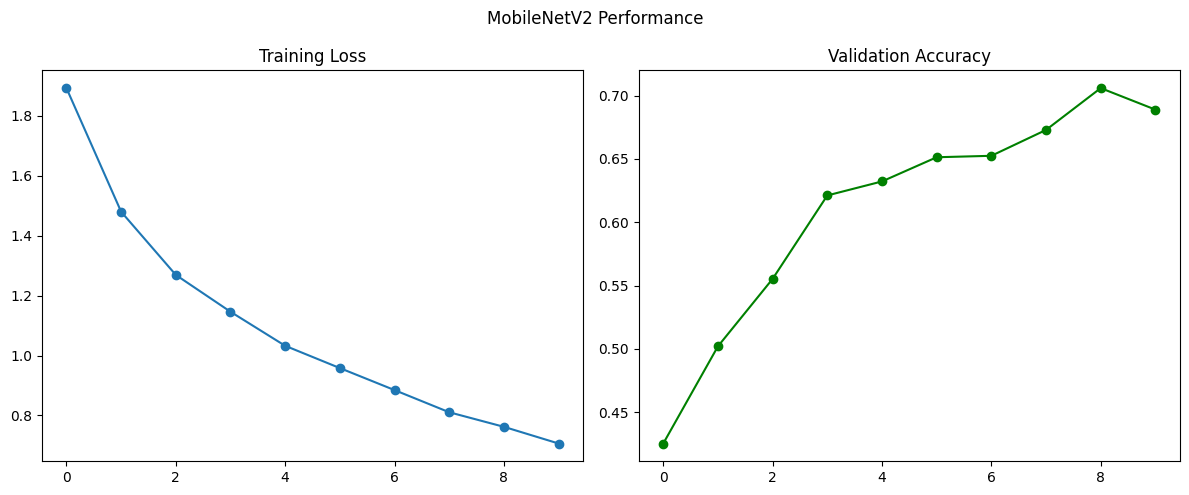

In [ ]:
# ========================
# MOBILENETV2 TRAINING BLOCK
# ========================

# 1. Model Initialization
mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 10)  # 10 classes
mobilenet.to(device)

# 2. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.parameters(), lr=0.001)

# 3. Training Loop
mobilenet_train_losses = []
mobilenet_val_metrics = []
start_time = time.time()

print("\n=== Training MobileNetV2 ===")
for epoch in range(epochs):
    epoch_start = time.time()

    # Training
    mobilenet.train()
    train_loss = train_one_epoch(mobilenet, train_loader, optimizer, criterion, device)

    # Validation
    val_metrics = evaluate(mobilenet, val_loader, criterion, device)

    # 🔹 Added: Extract predictions and labels
    y_true = val_metrics.get('true_labels', [])
    y_pred = val_metrics.get('predictions', [])

    # 🔹 Added: Compute precision, recall, and F1 only if predictions exist
    if y_true and y_pred:
        f1 = f1_score(y_true, y_pred, average='macro')
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        print(f"F1 = {f1:.4f} | Precision = {precision:.4f} | Recall = {recall:.4f}")

    # Store results
    mobilenet_train_losses.append(train_loss)
    mobilenet_val_metrics.append(val_metrics)

    # Print progress
    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss = {train_loss:.4f} | "
          f"Val Acc = {val_metrics['accuracy']:.4f} | "
          f"Time = {time.time()-epoch_start:.1f}s")

# 4. Results
print(f"\nMobileNetV2 Training Complete (Total: {(time.time()-start_time)/60:.1f} min)")
print(f"Final Validation Accuracy: {mobilenet_val_metrics[-1]['accuracy']:.4f}")

# 5. Plotting
plt.figure(figsize=(12,5))
plt.suptitle("MobileNetV2 Performance")
plt.subplot(1,2,1)
plt.plot(mobilenet_train_losses, marker='o')
plt.title("Training Loss")
plt.subplot(1,2,2)
plt.plot([m['accuracy'] for m in mobilenet_val_metrics], marker='o', color='green')
plt.title("Validation Accuracy")
plt.tight_layout()
plt.show()



=== Training EfficientNet-B0 ===


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1 = 0.3510 | Precision = 0.3781 | Recall = 0.3558
Epoch 1/10: Train Loss = 1.8361 | Val Acc = 0.4086 | Time = 2137.9s
F1 = 0.5032 | Precision = 0.5654 | Recall = 0.5199
Epoch 2/10: Train Loss = 1.3868 | Val Acc = 0.5817 | Time = 2111.7s
F1 = 0.5820 | Precision = 0.6149 | Recall = 0.5774
Epoch 3/10: Train Loss = 1.1574 | Val Acc = 0.6261 | Time = 2110.0s
F1 = 0.5955 | Precision = 0.6487 | Recall = 0.5881
Epoch 4/10: Train Loss = 1.0082 | Val Acc = 0.6542 | Time = 2120.5s
F1 = 0.6481 | Precision = 0.7051 | Recall = 0.6370
Epoch 5/10: Train Loss = 0.9013 | Val Acc = 0.6857 | Time = 2101.7s
F1 = 0.6740 | Precision = 0.6812 | Recall = 0.6862
Epoch 6/10: Train Loss = 0.7983 | Val Acc = 0.6931 | Time = 2139.0s
F1 = 0.7169 | Precision = 0.7193 | Recall = 0.7261
Epoch 7/10: Train Loss = 0.6964 | Val Acc = 0.7405 | Time = 2151.9s
F1 = 0.7168 | Precision = 0.7235 | Recall = 0.7163
Epoch 8/10: Train Loss = 0.6134 | Val Acc = 0.7378 | Time = 2213.4s
F1 = 0.7361 | Precision = 0.7473 | Recall = 0.73

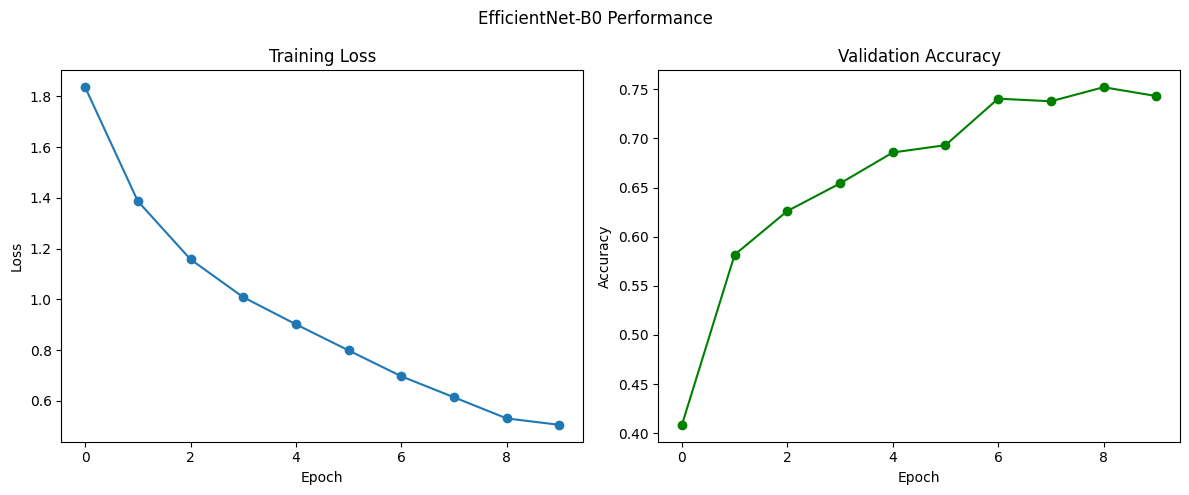

In [ ]:
# ========================
# EFFICIENTNET-B0 TRAINING BLOCK
# ========================

# 1. Model Initialization
efficientnet = models.efficientnet_b0(weights=None)  # No pretrained weights
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 10)  # 10 classes
efficientnet.to(device)

# 2. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet.parameters(), lr=0.001)
epochs = 10

# 3. Training Loop
efficientnet_train_losses = []
efficientnet_val_metrics = []
start_time = time.time()

print("\n=== Training EfficientNet-B0 ===")
for epoch in range(epochs):
    epoch_start = time.time()

    # Training
    efficientnet.train()
    train_loss = train_one_epoch(efficientnet, train_loader, optimizer, criterion, device)

    # Validation
    val_metrics = evaluate(efficientnet, val_loader, criterion, device)

    # Extract predictions and labels
    y_true = val_metrics.get('true_labels', [])
    y_pred = val_metrics.get('predictions', [])

    # Compute and display metrics
    if y_true and y_pred:
        f1 = f1_score(y_true, y_pred, average='macro')
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        print(f"F1 = {f1:.4f} | Precision = {precision:.4f} | Recall = {recall:.4f}")
    else:
        f1 = precision = recall = 0.0

    # Store results
    efficientnet_train_losses.append(train_loss)
    efficientnet_val_metrics.append(val_metrics)

    # Print progress
    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss = {train_loss:.4f} | "
          f"Val Acc = {val_metrics['accuracy']:.4f} | "
          f"Time = {time.time()-epoch_start:.1f}s")

# 4. Results
print(f"\nEfficientNet-B0 Training Complete (Total: {(time.time()-start_time)/60:.1f} min)")
print(f"Final Validation Accuracy: {efficientnet_val_metrics[-1]['accuracy']:.4f}")

# 5. Plotting
plt.figure(figsize=(12,5))
plt.suptitle("EfficientNet-B0 Performance")

plt.subplot(1,2,1)
plt.plot(efficientnet_train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot([m['accuracy'] for m in efficientnet_val_metrics], marker='o', color='green')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

=== Training SimpleCNN ===
Epoch 1/10: Train Loss = 1.7902 | Val Accuracy = 0.4819
Epoch 2/10: Train Loss = 1.3297 | Val Accuracy = 0.5590
Epoch 3/10: Train Loss = 1.0679 | Val Accuracy = 0.5830
Epoch 4/10: Train Loss = 0.7901 | Val Accuracy = 0.6042
Epoch 5/10: Train Loss = 0.5090 | Val Accuracy = 0.5981
Epoch 6/10: Train Loss = 0.2988 | Val Accuracy = 0.5990
Epoch 7/10: Train Loss = 0.1599 | Val Accuracy = 0.5855
Epoch 8/10: Train Loss = 0.0912 | Val Accuracy = 0.5884
Epoch 9/10: Train Loss = 0.0728 | Val Accuracy = 0.5897
Epoch 10/10: Train Loss = 0.0711 | Val Accuracy = 0.5746

Training completed in 79.7 minutes
Final Validation Accuracy: 0.5746


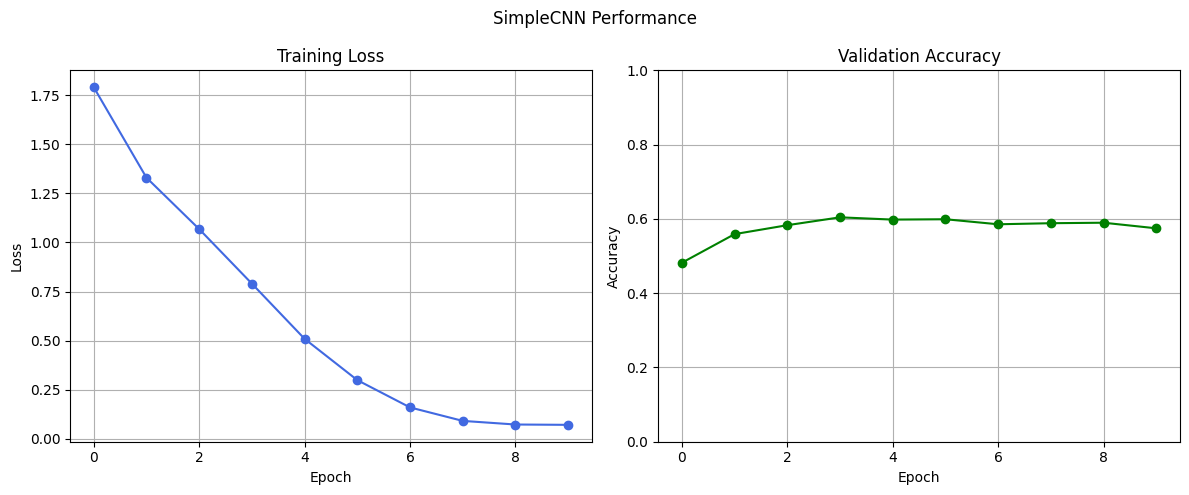


Sample Predictions:
True: spider     | Predicted: spider
True: sheep      | Predicted: sheep
True: dog        | Predicted: dog
True: chicken    | Predicted: chicken
True: chicken    | Predicted: dog


In [ ]:
# =============================================
# 1. Define Simple CNN Model
# =============================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)   # [3,128,128] -> [16,128,128]
        self.pool = nn.MaxPool2d(2, 2)                # -> [16,64,64]
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # [16,64,64] -> [32,64,64]
                                                     # after pool -> [32,32,32]
        self.fc1 = nn.Linear(32 * 32 * 32, 128)       # Flattened -> 32*32*32
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Conv1 + ReLU + Pool
        x = self.pool(F.relu(self.conv2(x)))  # Conv2 + ReLU + Pool
        x = x.view(x.size(0), -1)             # Flatten for FC
        x = F.relu(self.fc1(x))               # Hidden layer
        x = self.fc2(x)                       # Output logits
        return x

# =============================================
# 2. Data Preparation (Transform, Loaders)
# =============================================
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Update this path to your dataset
data_path = '/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/animal_10/raw-img'

# Load full dataset
full_dataset = datasets.ImageFolder(root=data_path, transform=transform)
class_names = full_dataset.classes
num_classes = len(class_names)

# Split dataset (80% train, 20% val)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# =============================================
# 3. Training Setup
# =============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
epochs = 10

# =============================================
# 4. Training Loop
# =============================================
train_losses = []
val_accuracies = []
start_time = time.time()

print("=== Training SimpleCNN ===")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss = {avg_loss:.4f} | "
          f"Val Accuracy = {val_accuracy:.4f}")

print(f"\nTraining completed in {(time.time() - start_time)/60:.1f} minutes")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")

# =============================================
# 5. Plot Training Loss & Validation Accuracy
# =============================================
plt.figure(figsize=(12, 5))
plt.suptitle("SimpleCNN Performance")

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', color='royalblue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, marker='o', color='green')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)

plt.tight_layout()
plt.show()

# =============================================
# 6. Sample Predictions
# =============================================
model.eval()
with torch.no_grad():
    images, labels = next(iter(val_loader))
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

print("\nSample Predictions:")
for i in range(5):
    true_label = labels[i].item()
    pred_label = preds[i].item()
    true_class = class_names[true_label]
    pred_class = class_names[pred_label]
    print(f"True: {true_class:<10} | Predicted: {pred_class}")

# Add F1, use better architecture or augment data
# Underfitting (model too simple)
#

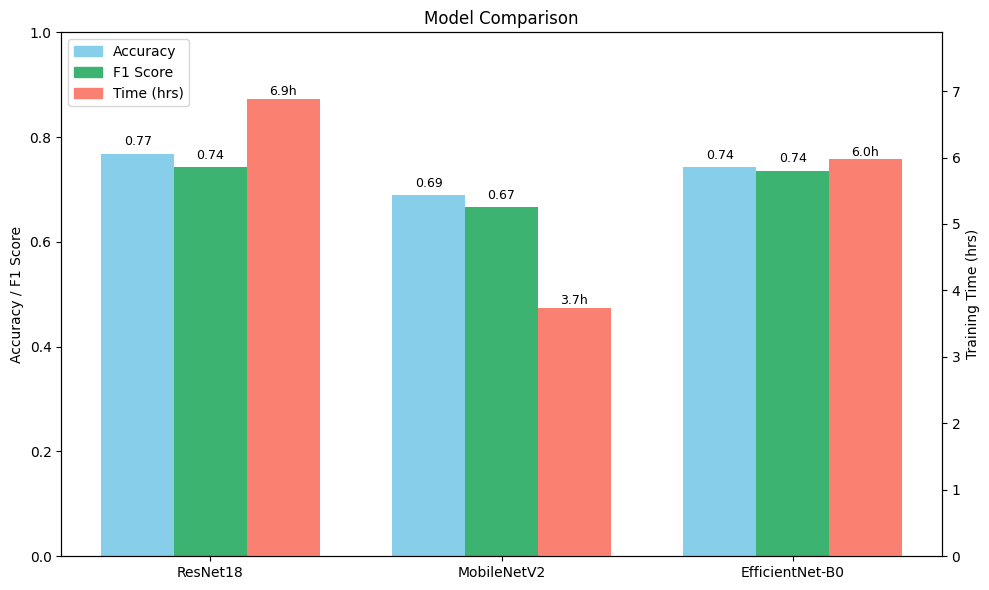

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['ResNet18', 'MobileNetV2', 'EfficientNet-B0']
accuracy = [0.7683, 0.6889, 0.7431]
f1 = [0.7424, 0.6660, 0.7361]
time_hrs = [413/60, 224.1/60, 358.3/60]

x = np.arange(len(models))
w = 0.25

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Bars
b1 = ax1.bar(x - w, accuracy, w, label='Accuracy', color='skyblue')
b2 = ax1.bar(x, f1, w, label='F1 Score', color='mediumseagreen')
b3 = ax2.bar(x + w, time_hrs, w, label='Time (hrs)', color='salmon')

# Add values above bars
for bars, ax, fmt in [(b1, ax1, "{:.2f}"), (b2, ax1, "{:.2f}"), (b3, ax2, "{:.1f}h")]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, fmt.format(h),
                ha='center', va='bottom', fontsize=9)

# Labels & legend
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylabel("Accuracy / F1 Score")
ax2.set_ylabel("Training Time (hrs)")
ax1.set_ylim(0, 1)
ax2.set_ylim(0, max(time_hrs) + 1)
ax1.set_title("Model Comparison")

# Custom legend
colors = ['skyblue', 'mediumseagreen', 'salmon']
labels = ['Accuracy', 'F1 Score', 'Time (hrs)']
ax1.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in colors], labels, loc='upper left')

plt.tight_layout()
plt.show()


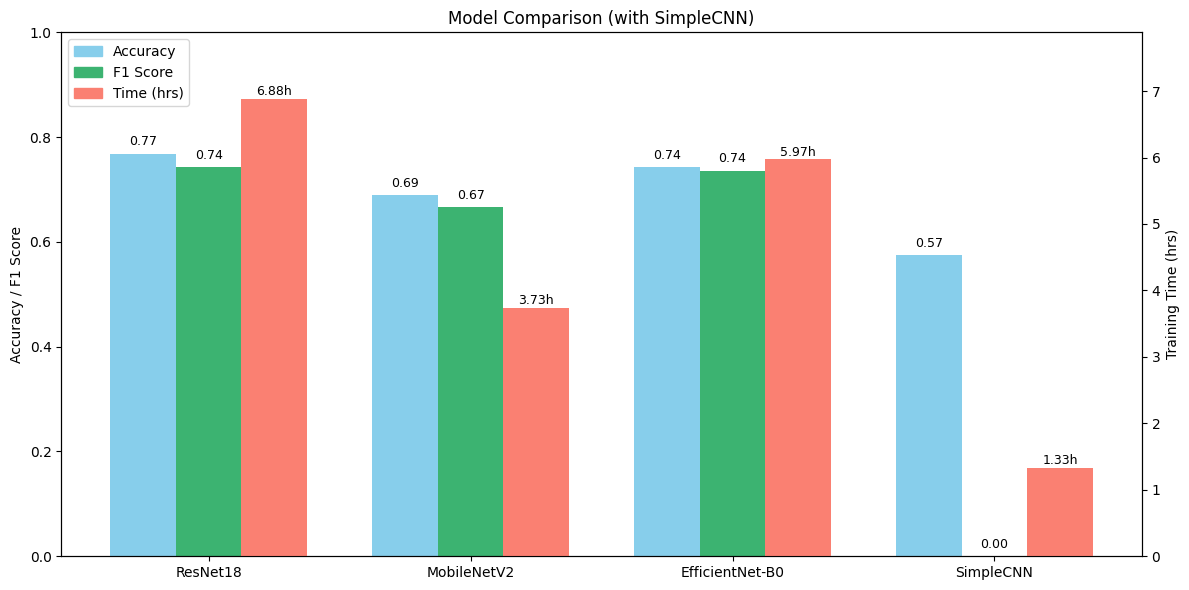

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Updated Data including SimpleCNN
models = ['ResNet18', 'MobileNetV2', 'EfficientNet-B0', 'SimpleCNN']
accuracy = [0.7683, 0.6889, 0.7431, 0.5746]
f1 = [0.7424, 0.6660, 0.7361, 0.00]  # You can update with actual F1 if calculated
time_hrs = [413/60, 224.1/60, 358.3/60, 79.7/60]

x = np.arange(len(models))
w = 0.25

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Bars
b1 = ax1.bar(x - w, accuracy, w, label='Accuracy', color='skyblue')
b2 = ax1.bar(x, f1, w, label='F1 Score', color='mediumseagreen')
b3 = ax2.bar(x + w, time_hrs, w, label='Time (hrs)', color='salmon')

# Add values above bars
for bars, ax, fmt in [(b1, ax1, "{:.2f}"), (b2, ax1, "{:.2f}"), (b3, ax2, "{:.2f}h")]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, fmt.format(h),
                ha='center', va='bottom', fontsize=9)

# Axis settings
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylabel("Accuracy / F1 Score")
ax2.set_ylabel("Training Time (hrs)")
ax1.set_ylim(0, 1)
ax2.set_ylim(0, max(time_hrs) + 1)
ax1.set_title("Model Comparison (with SimpleCNN)")

# Legend
colors = ['skyblue', 'mediumseagreen', 'salmon']
labels = ['Accuracy', 'F1 Score', 'Time (hrs)']
ax1.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in colors], labels, loc='upper left')

plt.tight_layout()
plt.show()
